In [1]:
#!pip install missingno

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno  # For visualizing missing data

In [3]:
# Load dataset
df = pd.read_csv('heart.csv')

In [4]:
# Check for missing values
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

<AxesSubplot:>

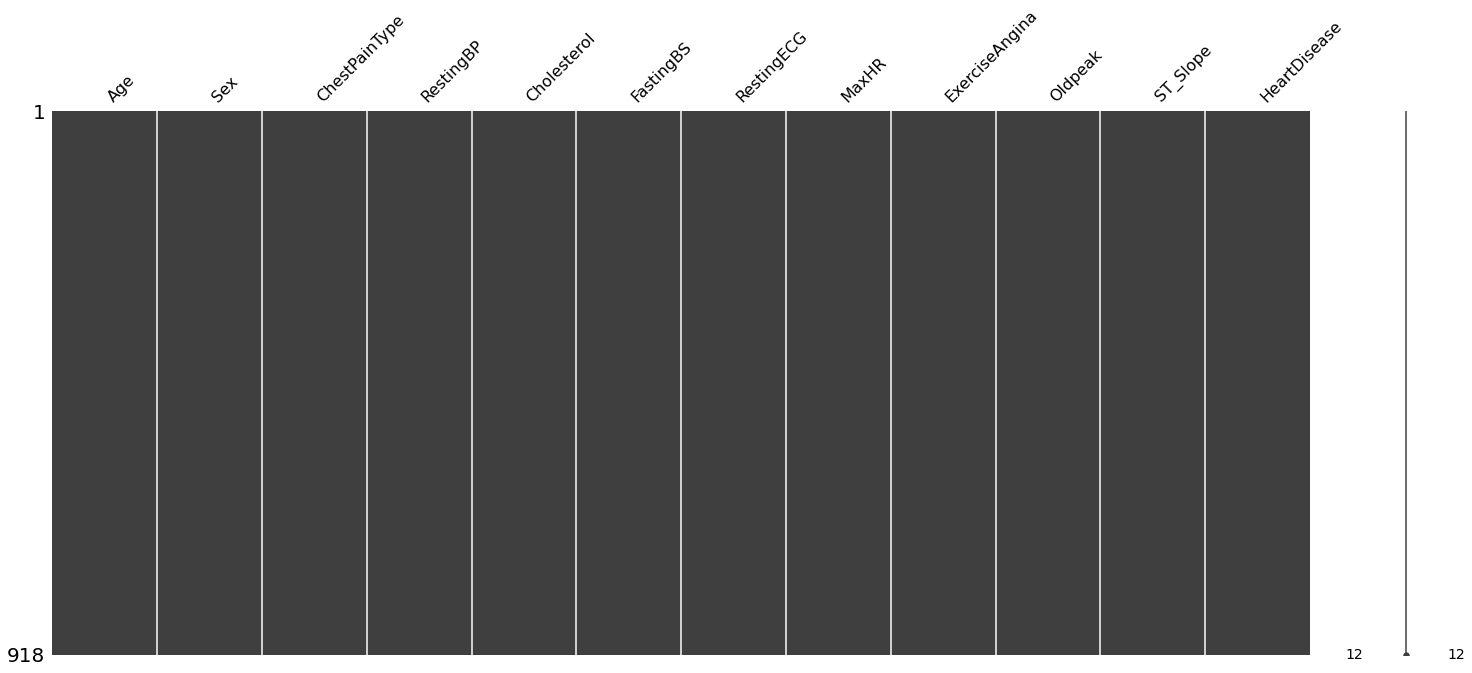

In [5]:
# Visualize missing data
msno.matrix(df)

In [6]:
# Dropping rows with missing values
df_clean = df.dropna()

In [7]:
# Filling missing values with mean/median
df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].mean())

<AxesSubplot:xlabel='Cholesterol'>

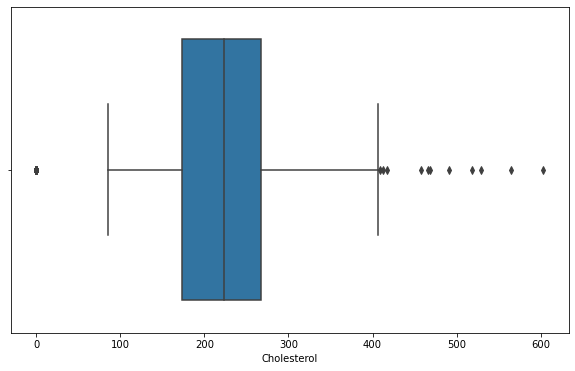

In [8]:
# Visualize outliers with a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Cholesterol'])

In [9]:
# Remove outliers using IQR
Q1 = df['Cholesterol'].quantile(0.25)
Q3 = df['Cholesterol'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[~((df['Cholesterol'] < (Q1 - 1.5 * IQR)) | (df['Cholesterol'] > (Q3 + 1.5 * IQR)))]


In [10]:
# Remove duplicates
df_clean = df.drop_duplicates()

In [11]:
# Descriptive statistics
df_clean.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [12]:
# Mean, Median, Mode for specific columns
mean_value = df_clean['Cholesterol'].mean()
median_value = df_clean['Cholesterol'].median()
mode_value = df_clean['Cholesterol'].mode()


Text(0.5, 1.0, 'Distribution of Cholesterol')

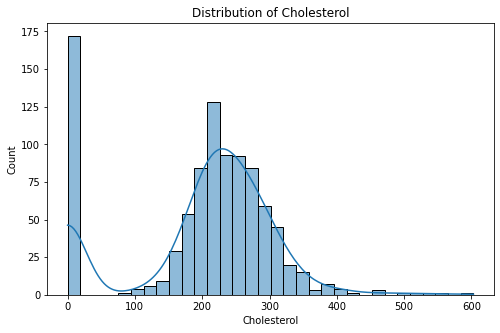

In [13]:
# Plotting a histogram
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['Cholesterol'], kde=True)
plt.title('Distribution of Cholesterol')

Text(0.5, 1.0, 'Correlation Matrix')

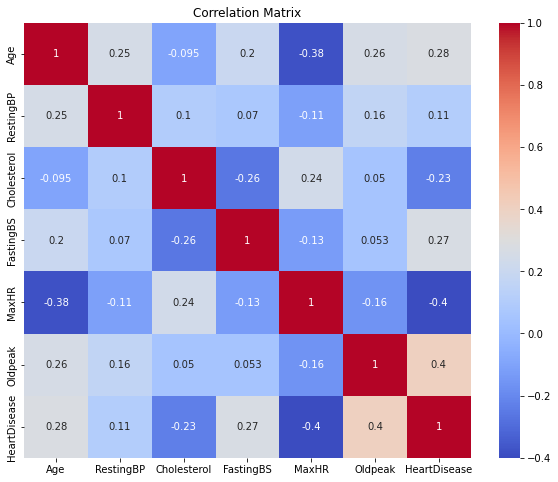

In [14]:
# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')


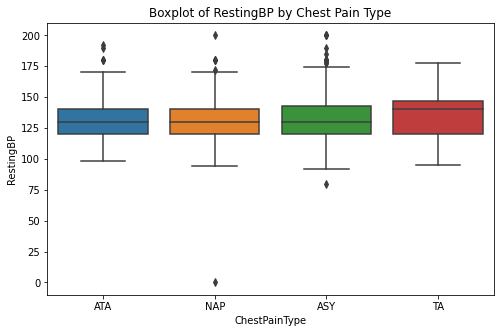

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='ChestPainType', y='RestingBP', data=df_clean)
plt.title('Boxplot of RestingBP by Chest Pain Type')
plt.show()

Text(0.5, 1.0, 'Histogram of Cholesterol')

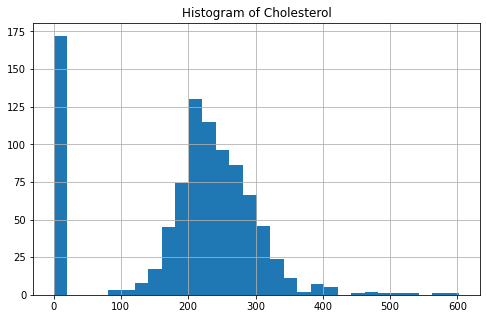

In [17]:
plt.figure(figsize=(8, 5))
df_clean['Cholesterol'].hist(bins=30)
plt.title('Histogram of Cholesterol')

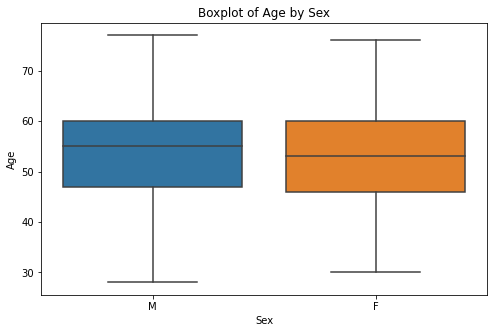

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Sex', y='Age', data=df_clean)
plt.title('Boxplot of Age by Sex')
plt.show()